# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb  # pip install wbgapi if not used before

In [ ]:
def plot_journal_time_series(indicator_id, country_codes, title, ylabel, bottom_text, source="World Bank (WDI)"):
    """
    Plots WB time-series data with unified Journal styling.
    """
    # Download data
    df = wb.data.DataFrame(indicator_id, country_codes, time=range(1960, 2024), numericTimeKeys=True).T
    
    # Color Palette
    journal_colors = [
        "#AD1457", # Raspberry Red
        "#2E7D32", # Forest Green
        "#C62828", # Deep Red/Burgundy
        "#F9A825", # Muted Ochre/Gold
        "#00838F", # Dark Teal
        "#6A1B9A", # Royal Purple
        "#4E342E", # Coffee/Earth
        "#1565C0", # Mid-Blue
        "#EF6C00", # Terracotta/Orange
        "#455A64"  # Blue-Grey/Slate
    ]
    
    # Figure Setup
    fig, ax = plt.subplots(figsize=(14, 8), dpi=200)
    sns.set_theme(style="whitegrid", rc={"grid.color": "#e5e5e5"})
    
    # Alignment Variable
    start_x = 0.12
    
    # Plotting
    df.plot(ax=ax, linewidth=2.5, color=journal_colors[:len(country_codes)])
    
    # Formatting
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color='#091731')
    
    # Remove default legend and create a clean one
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.08), 
              ncol=len(country_codes), fontsize=10)
    
    # Text & Lines (Figure coordinates for consistent alignment)
    # Title
    plt.figtext(start_x, 0.92, title, fontsize=26, fontweight='bold', color='#091731')
    
    # Horizontal Accent Line
    line = plt.Line2D([start_x, 0.9], [0.89, 0.89], transform=fig.transFigure, color='#091731', linewidth=1.5)
    fig.add_artist(line)
    
    # Bottom Text
    plt.figtext(start_x, 0.12, bottom_text, fontsize=12, color='#091731', linespacing=1.6)
    
    # Source
    plt.figtext(start_x, 0.07, f"Source: {source}", 
                fontsize=9, color='gray', style='italic')
    
    plt.tight_layout(rect=[0.08, 0.15, 0.95, 0.88])
    plt.show()

# Execution
my_countries = ['JPN', 'USA', 'KOR', 'FRA', 'DEU', 'CHE', 'COL']


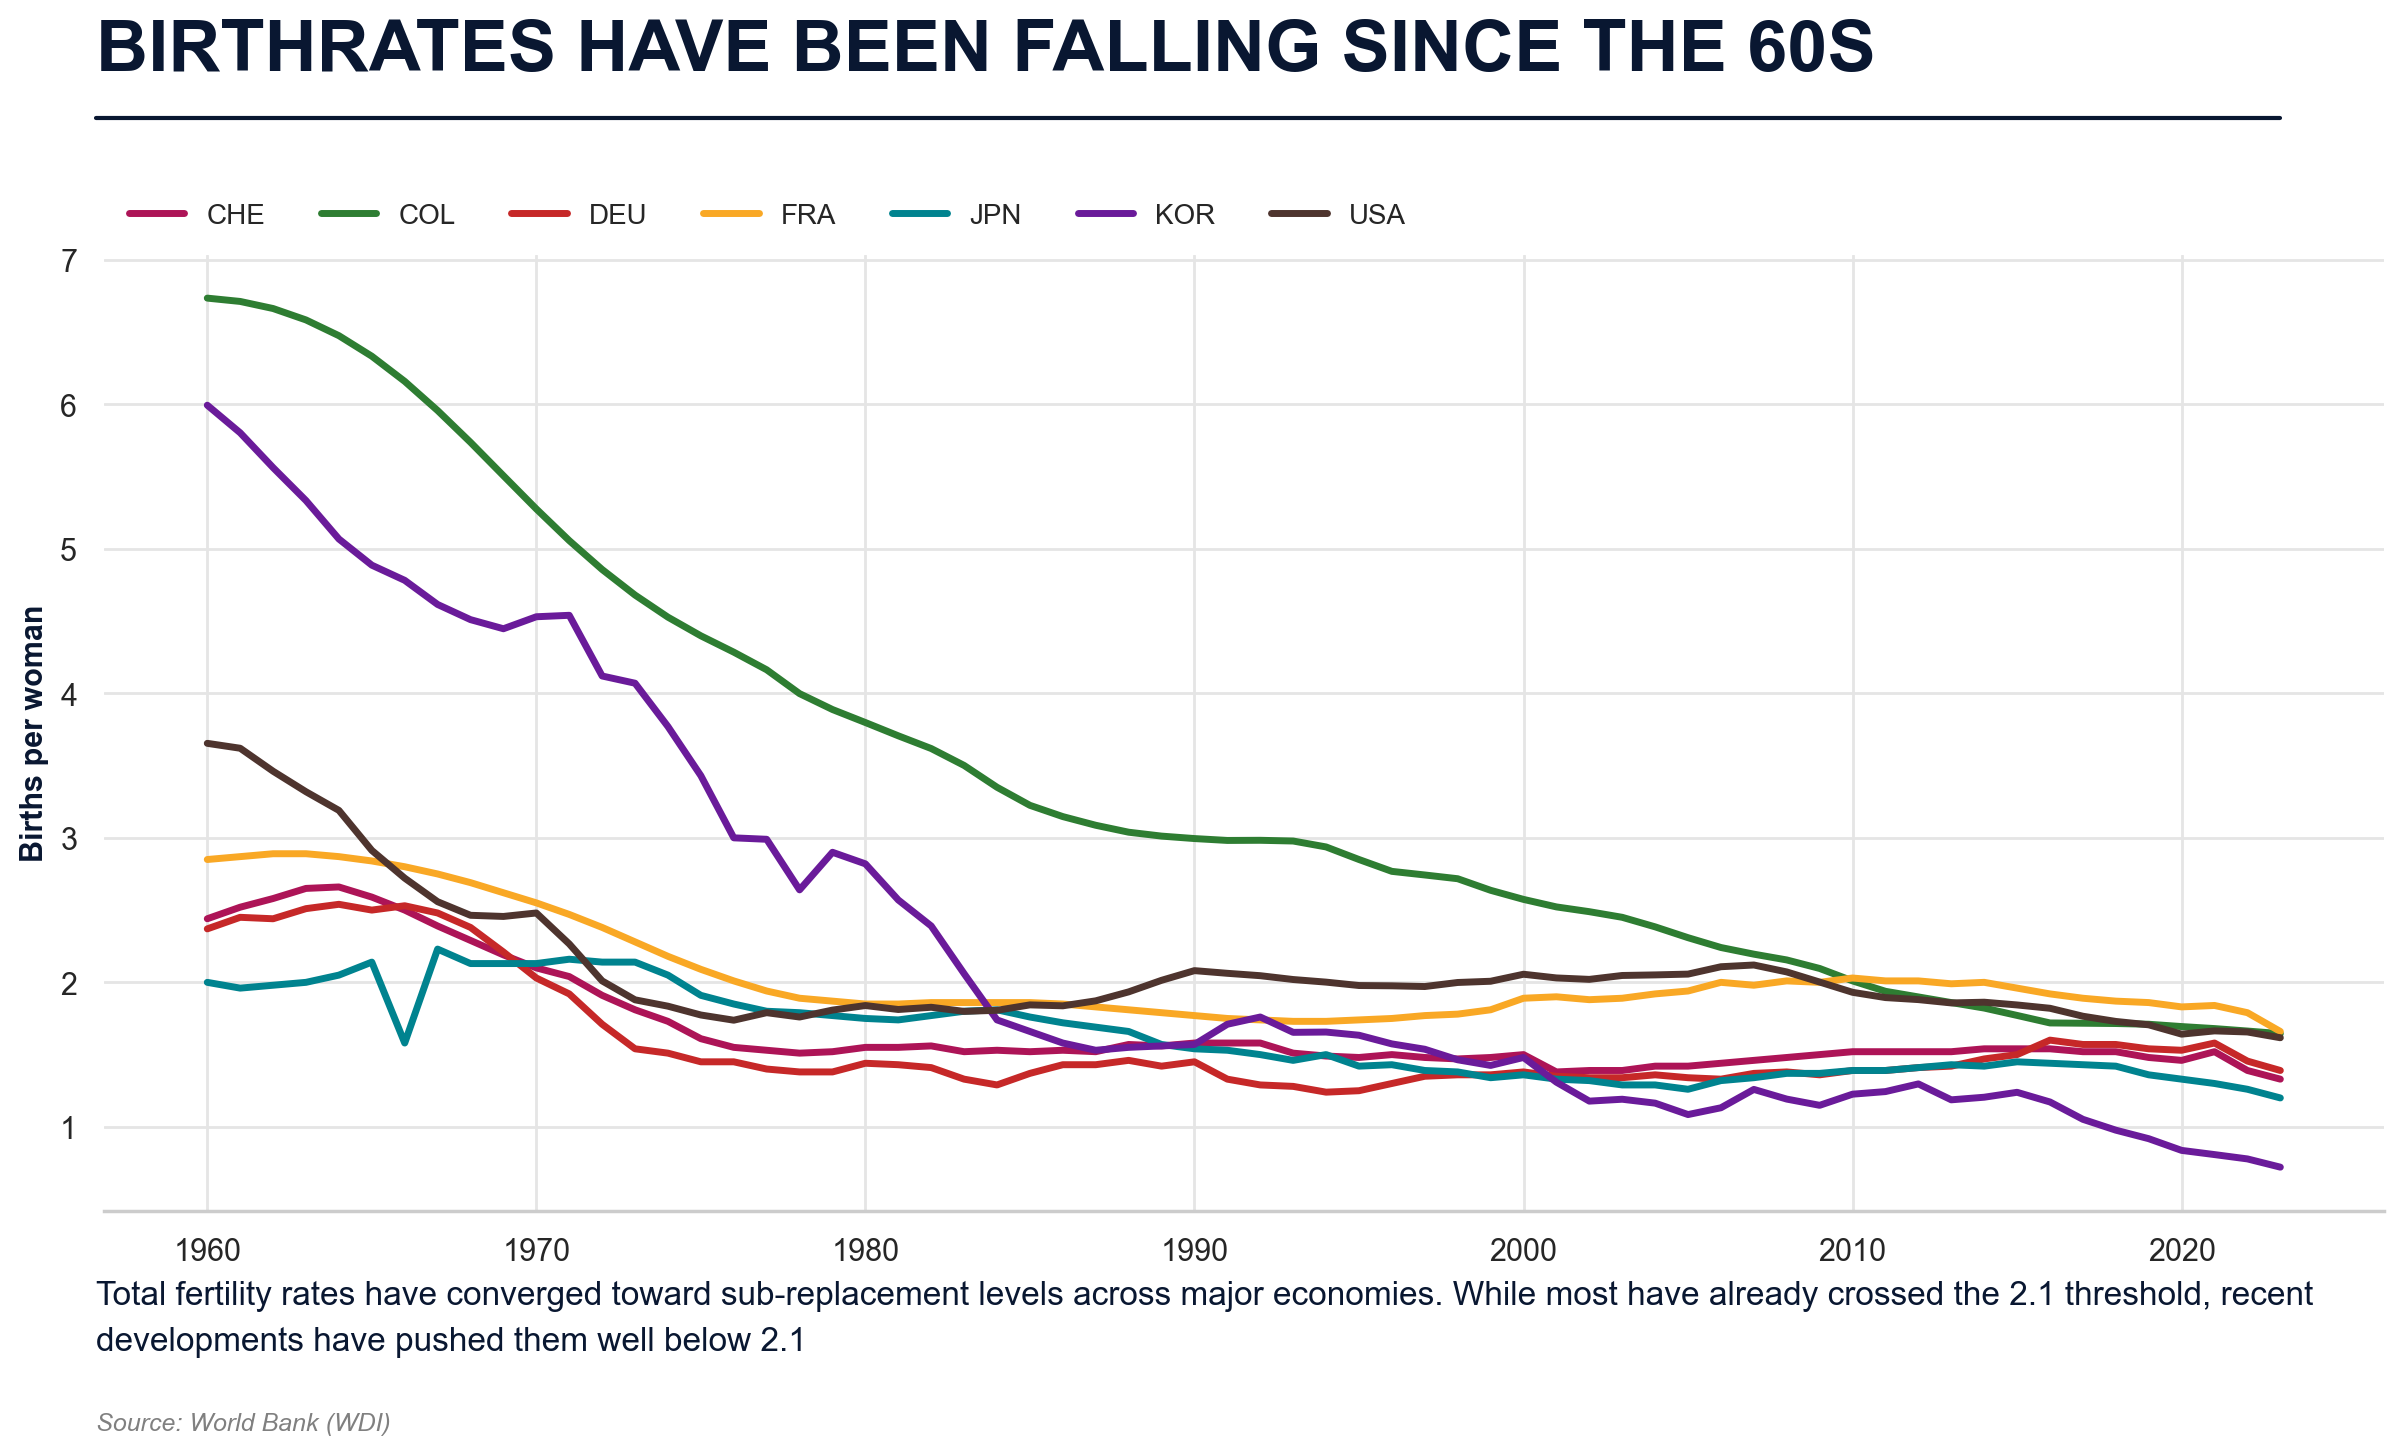

In [6]:

# Fertility Graph
plot_journal_time_series(
    indicator_id='SP.DYN.TFRT.IN', 
    country_codes=my_countries, 
    title="BIRTHRATES HAVE BEEN FALLING SINCE THE 60S", 
    ylabel="Births per woman",
    bottom_text="Total fertility rates have converged toward sub-replacement levels across major economies. While most have already crossed the 2.1 threshold, recent\ndevelopments have pushed them well below 2.1" )



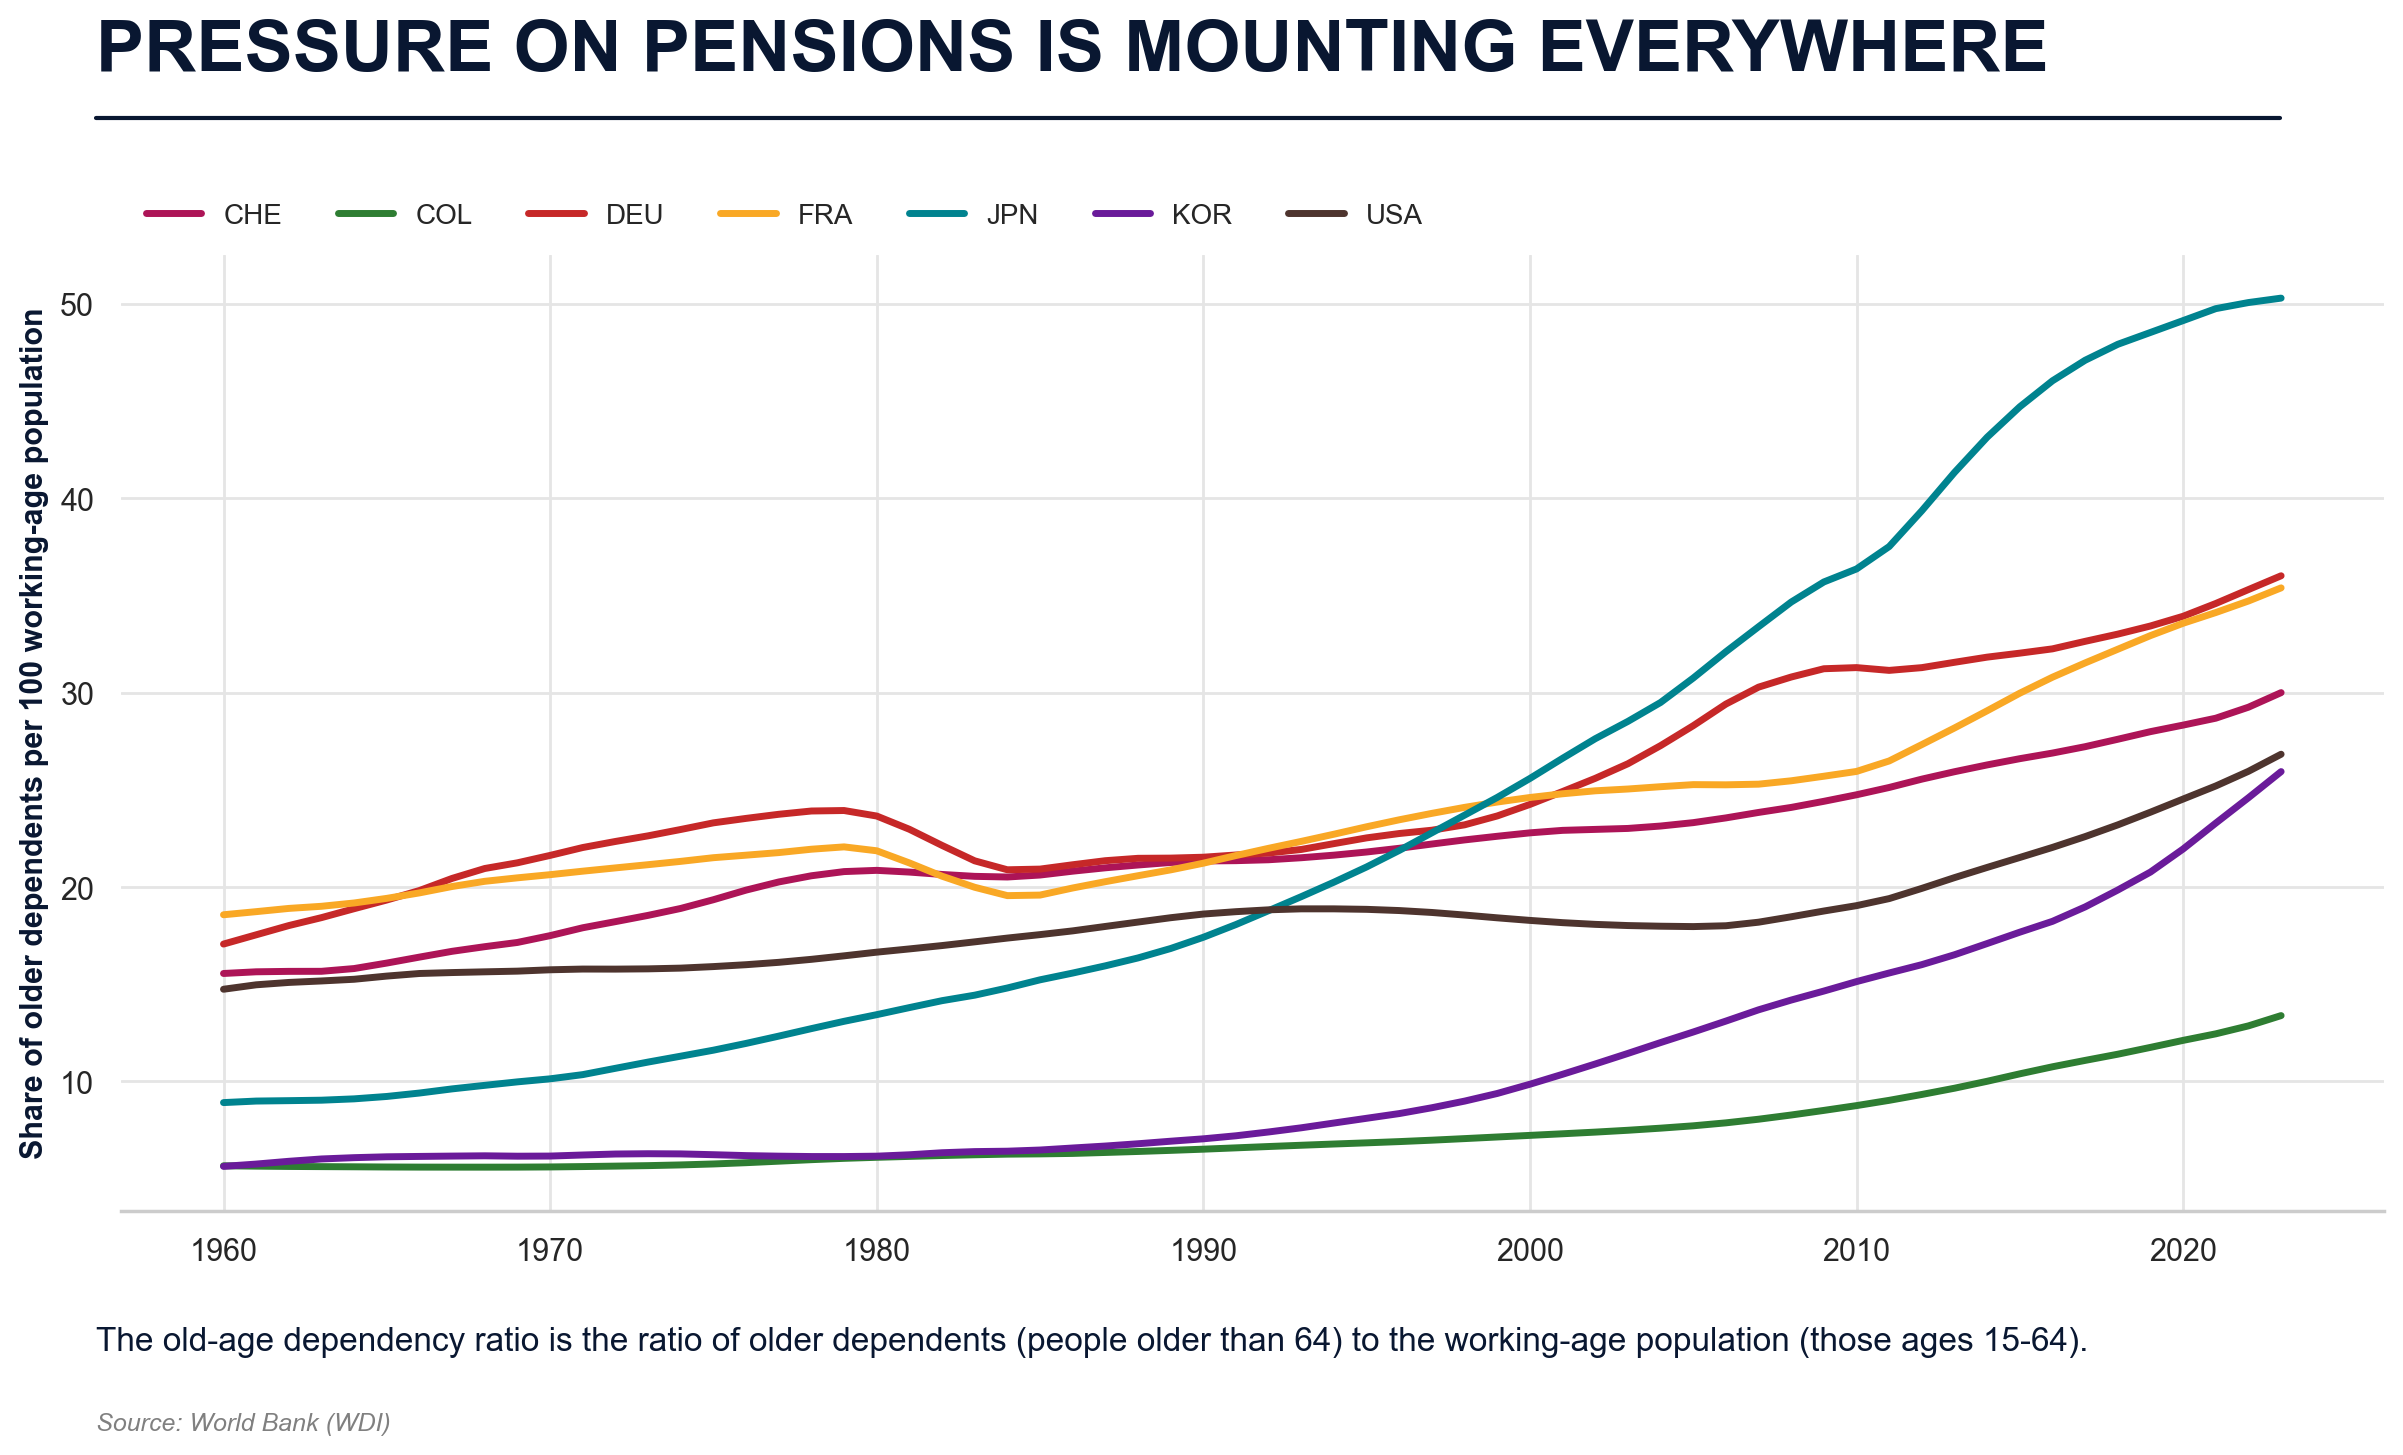

In [14]:
# Dependency Ratio Graph
plot_journal_time_series(
    indicator_id='SP.POP.DPND.OL', 
    country_codes=my_countries, 
    title="PRESSURE ON PENSIONS IS MOUNTING EVERYWHERE", 
    ylabel="Share of older dependents per 100 working-age population",
    bottom_text="The old-age dependency ratio is the ratio of older dependents (people older than 64) to the working-age population (those ages 15-64)."
)

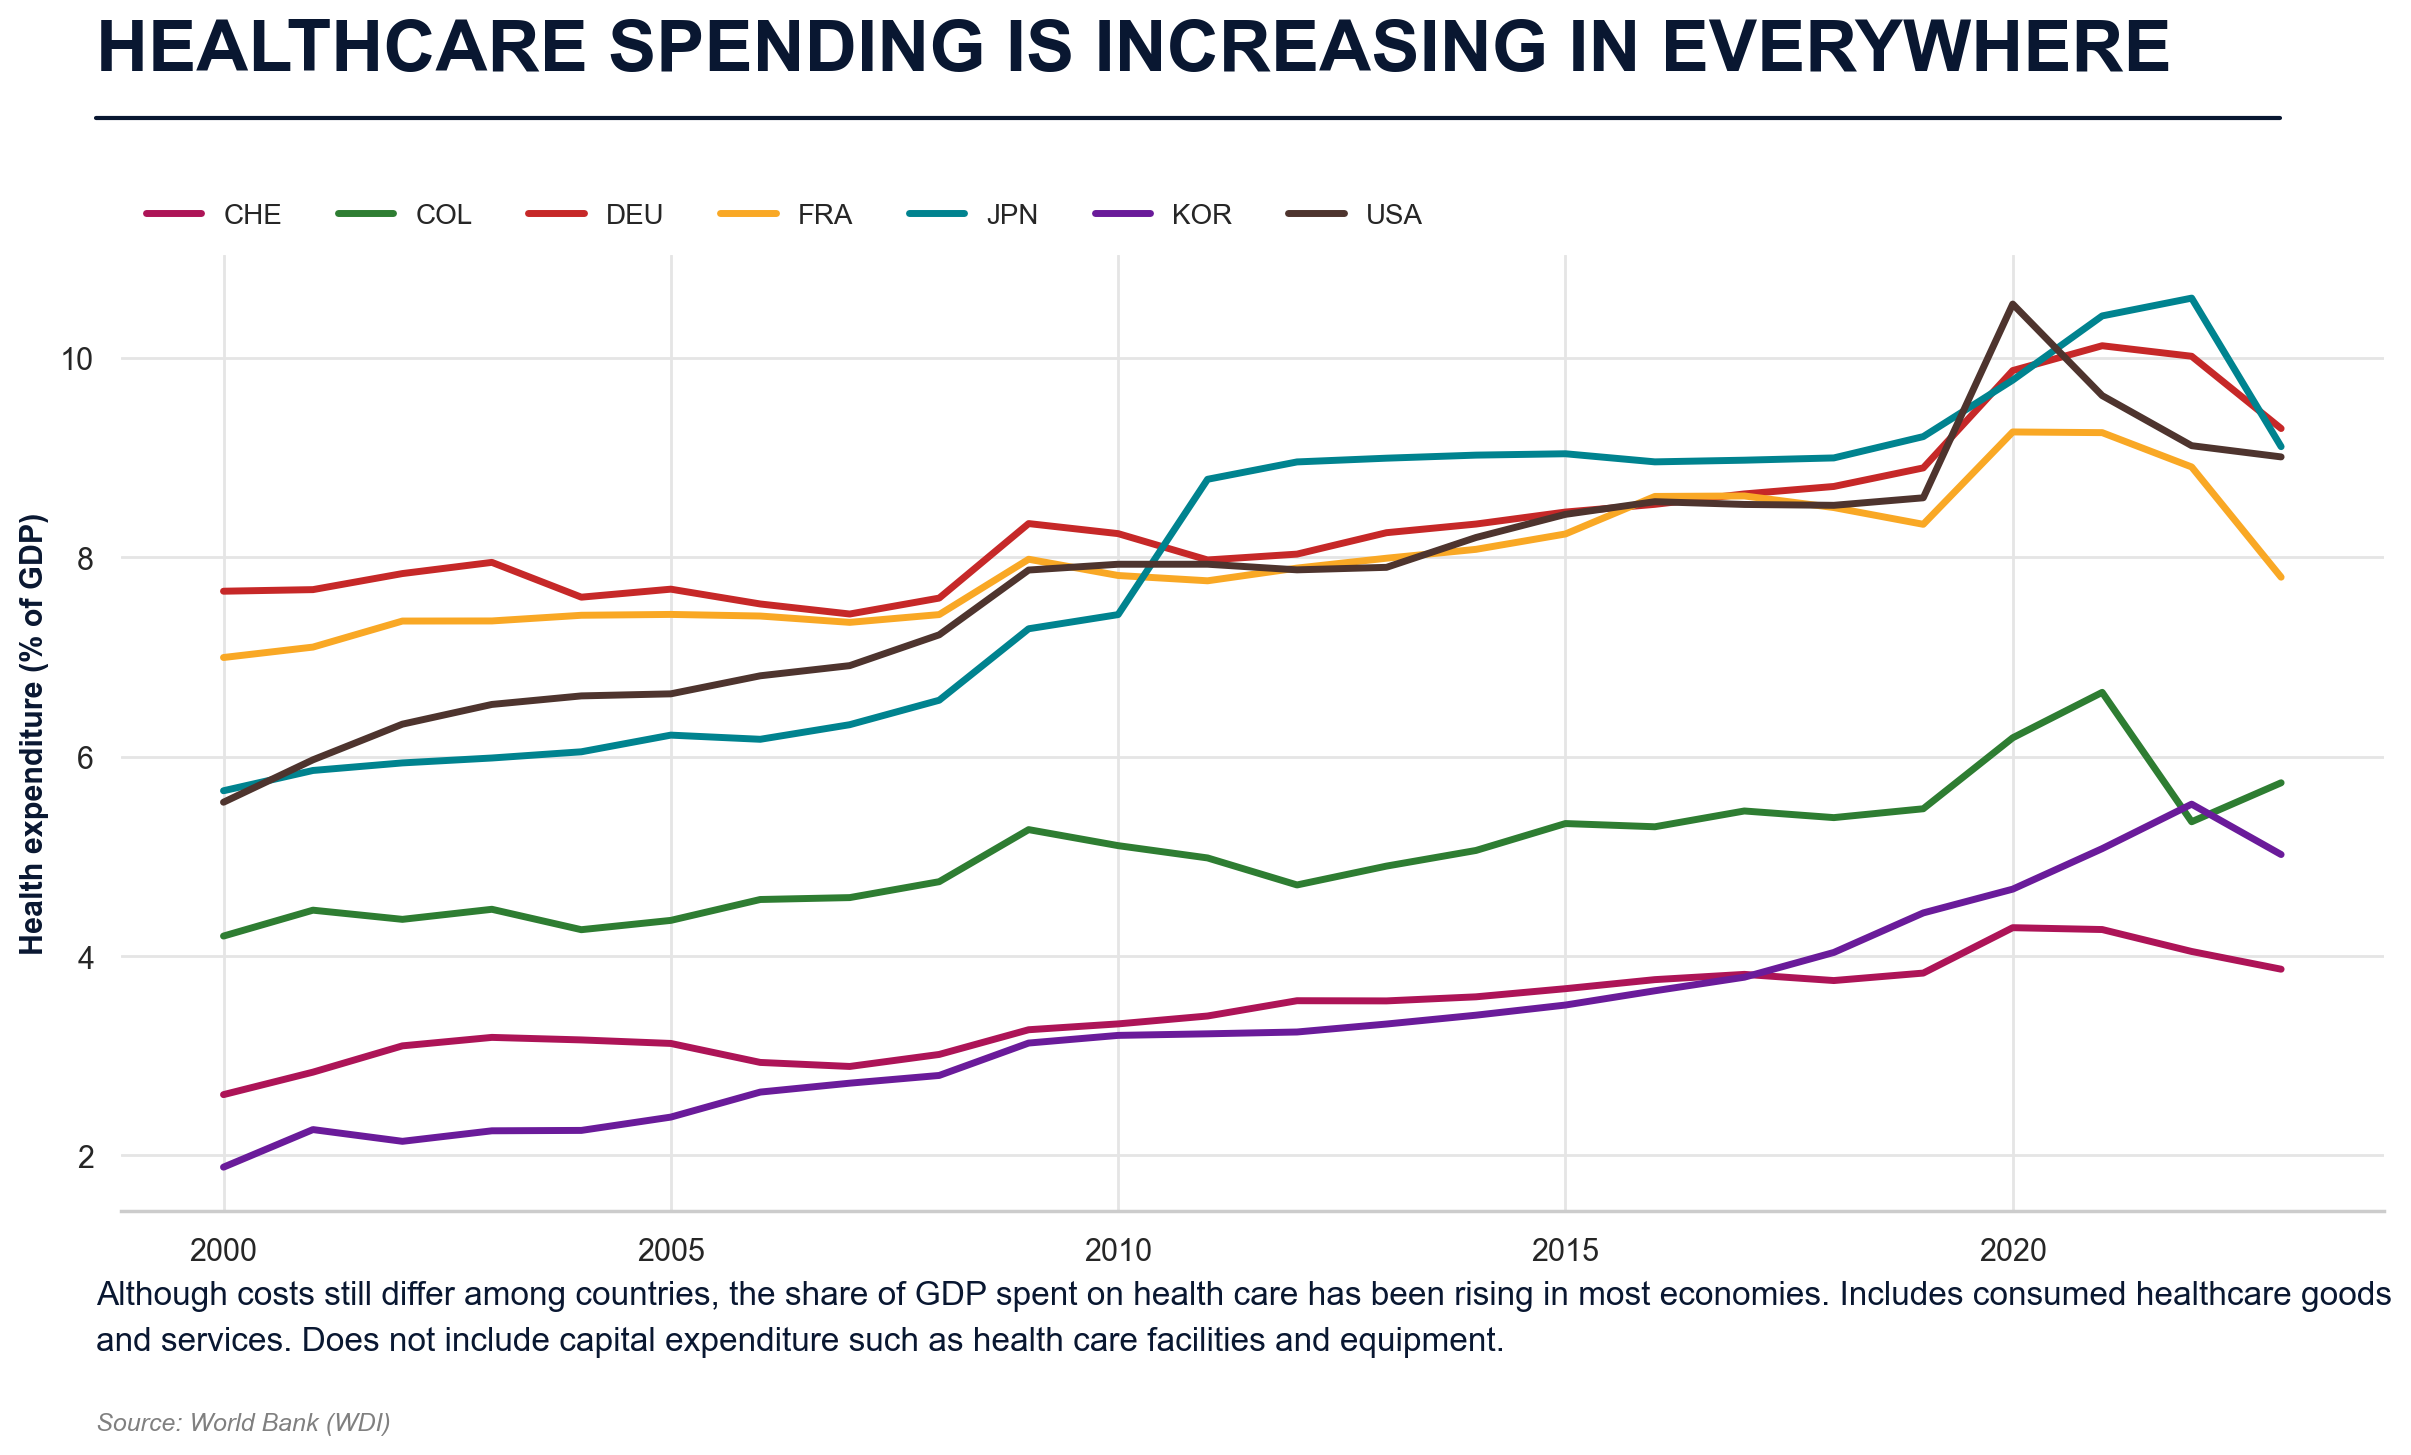

In [8]:
# Dependency Ratio Graph
plot_journal_time_series(
    indicator_id='SH.XPD.GHED.GD.ZS', 
    country_codes=my_countries, 
    title="HEALTHCARE SPENDING IS INCREASING IN EVERYWHERE", 
    ylabel="Health expenditure (% of GDP)",
    bottom_text="Although costs still differ among countries, the share of GDP spent on health care has been rising in most economies. Includes consumed healthcare goods\nand services. Does not include capital expenditure such as health care facilities and equipment."
)

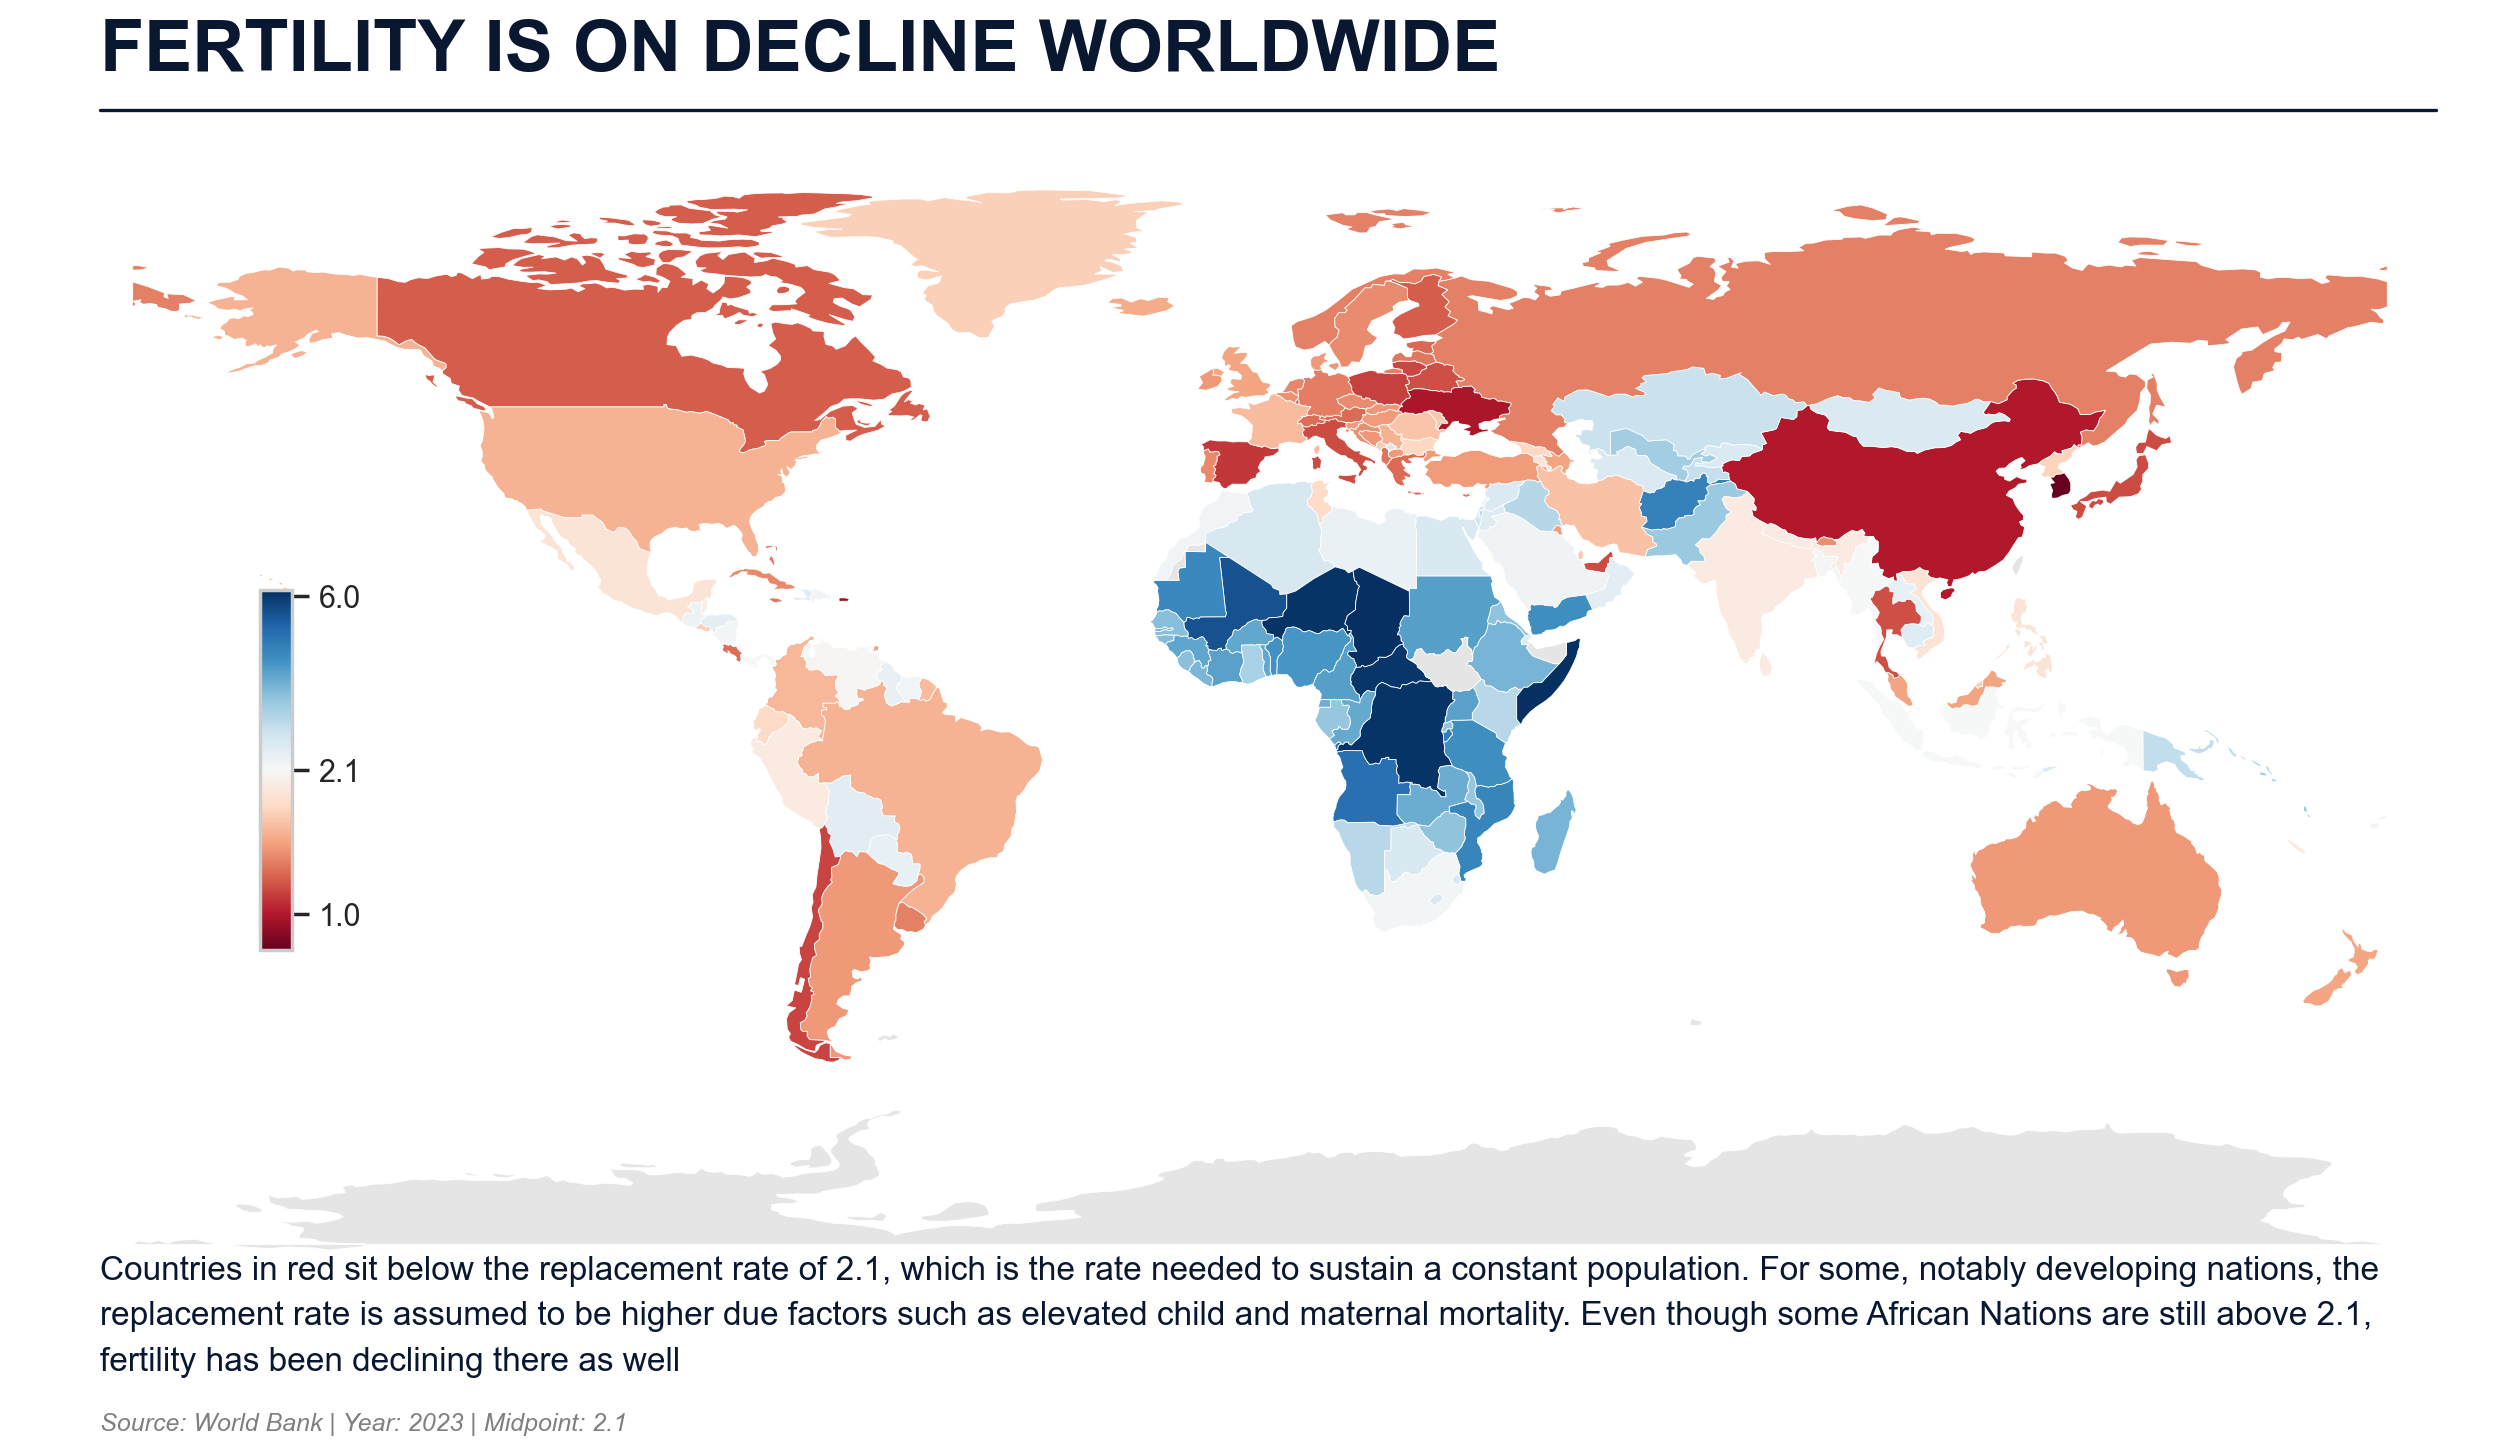

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import wbgapi as wb

def plot_journal_world_map(indicator_id, year, vcenter, title, bottom_text, source="World Bank"):
    """
    Final Correction:
    - Anchors all text to a unified 'start_x'.
    - Tightens vertical spacing to keep labels near the map.
    - Uses #091731 as the primary anchor color.
    """
    # Fetch Data
    df = wb.data.DataFrame(indicator_id, time=year, skipAggs=True).reset_index()
    
    # Load World Geometry
    world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
    world = gpd.read_file(world_url)
    
    # Merge
    merged = world.merge(df, left_on='id', right_on='economy', how='left')
    
    # Normalization
    vmin, vmax = merged[indicator_id].min(), merged[indicator_id].max()
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    
    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(16, 10), dpi=200)
    
    # Unified Alignment Variable ---
    # Adjust this to shift everything left or right
    start_x = 0.15 
    
    # Custom Axis for Colorbar
    cax = fig.add_axes([start_x + 0.05, 0.38, 0.01, 0.18]) 

    # Custom ticks: The bottom (1.0 or min), the center (vcenter), and the top (vmax)
    # Using 1.0 as the bottom tick
    custom_ticks = [max(1.0, vmin), vcenter, min(6.0, vmax)]
    
    # Plot the world
    merged.plot(column=indicator_id, ax=ax, 
                cmap='RdBu', norm=norm,
                edgecolor='white', linewidth=0.3,
                missing_kwds={"color": "#e5e5e5"},
                cax=cax, 
                legend=True,
                legend_kwds={'label': '',
                              'orientation': 'vertical',
                              'ticks': custom_ticks})
    
    ax.set_axis_off()
        
    # Header Title 
    plt.figtext(start_x, 0.82, title, fontsize=26, fontweight='bold', color='#091731')
    
    # Full-width Line below title
    line = plt.Line2D([start_x, 0.88], [0.80, 0.80], transform=fig.transFigure, color='#091731', linewidth=1.2)
    fig.add_artist(line)
    
    
    # Bottom Text 
    plt.figtext(start_x, 0.17, bottom_text, fontsize=12, color='#091731', linespacing=1.6)
    
    # Metadata & Source (Directly below bottom text)
    plt.figtext(start_x, 0.14, f"Source: {source} | Year: {year} | Midpoint: {vcenter}", 
                fontsize=9, color='gray', style='italic')

    plt.show()

# Execution
plot_journal_world_map(
    indicator_id='SP.DYN.TFRT.IN', 
    year=2023, 
    vcenter=2.1, 
    title="FERTILITY IS ON DECLINE WORLDWIDE",
    bottom_text="Countries in red sit below the replacement rate of 2.1, which is the rate needed to sustain a constant population. For some, notably developing nations, the\nreplacement rate is assumed to be higher due factors such as elevated child and maternal mortality. Even though some African Nations are still above 2.1,\nfertility has been declining there as well.",
)